# 01 · Visão geral dos resultados

F1 oficial do LoCoMo por categoria e condição, e as três comparações que
estruturam o estudo:

| comparação | isola |
|---|---|
| B3 → G1 | valor das faces (mesmos fatos extraídos) |
| G1 → G2 | valor da curadoria + consolidação |
| G2 → G3 | valor do sigma-agent |

Pré-requisito: `fgl run-all` (ou `fgl run-all --dry-run` + `setup(dry=True)`).


In [1]:
from nbutils import *

# results/ por padrão; use setup(dry=True) para inspecionar um smoke run offline
ctx = setup()
ctx.conditions


✓ 9 condition(s) from C:\Users\rodri\OneDrive\Documentos\GitHub\AIIMS\out_experiments\Projeto L\fatgraph-locomo\results: B1-full-context, B2-rag-turns, B3-rag-facts, G1-fatgraph-min, G2-fatgraph-cur, G3-fatgraph-agent, G4-fatgraph-sigma, G5-fatgraph-coverage, G6-fatgraph-join


['B1-full-context',
 'B2-rag-turns',
 'B3-rag-facts',
 'G1-fatgraph-min',
 'G2-fatgraph-cur',
 'G3-fatgraph-agent',
 'G4-fatgraph-sigma',
 'G5-fatgraph-coverage',
 'G6-fatgraph-join']

## Tabela principal


In [2]:
ctx.f1.pivot_table(index='condition', columns='category', values='f1', observed=True).round(3)


category,multi-hop,temporal,open-domain,single-hop,adversarial
condition,,,,,
B1-full-context,0.392,0.426,0.069,0.653,0.630
B2-rag-turns,0.177,0.330,0.042,0.366,0.729
B3-rag-facts,0.232,0.431,0.082,0.384,0.854
G1-fatgraph-min,0.142,0.386,0.052,0.316,0.895
G2-fatgraph-cur,0.138,0.330,0.058,0.304,0.904
G3-fatgraph-agent,0.147,0.346,0.064,0.298,0.888
G4-fatgraph-sigma,0.190,0.428,0.062,0.355,0.872
G5-fatgraph-coverage,0.150,0.374,0.065,0.300,0.899
G6-fatgraph-join,0.167,0.393,0.071,0.343,0.908


In [3]:
ctx.overall.round(3)


,n,f1_micro,f1_macro,abstention_rate,mean_context_tokens,sigma_expand,sigma_use_rate,sigma_facts_mean,sigma_tokens_mean,sigma_evidence_rate,...,sigma_over_budget_rate,face_coverage,coverage_link_rate,coverage_entities_mean,coverage_best_mean,coverage_bridge_rate,coverage_use_rate,coverage_facts_mean,geodesic_rate,coverage_evidence_rate
condition,,,,,,,,,,,,,,,,,,,,,
B1-full-context,1986,0.546,0.434,0.180,23278.1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B2-rag-turns,1986,0.399,0.329,0.401,421.4,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B3-rag-facts,1986,0.461,0.397,0.373,249.5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
G1-fatgraph-min,1986,0.420,0.358,0.494,2003.5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
G2-fatgraph-cur,1986,0.408,0.347,0.504,2007.4,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
G3-fatgraph-agent,1986,0.405,0.348,0.512,2007.6,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
G4-fatgraph-sigma,1986,0.445,0.381,0.423,1254.5,True,0.972,4.22,48.3,0.109,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
G5-fatgraph-coverage,1986,0.414,0.358,0.501,2006.2,NaN,NaN,NaN,NaN,NaN,...,NaN,True,0.994,1.88,0.955,0.568,0.994,19.96,0.0,0.440
G6-fatgraph-join,1986,0.440,0.376,0.455,1542.7,True,0.008,0.02,36.6,0.000,...,0.0,True,0.994,1.88,0.955,0.568,0.994,19.92,0.0,0.513


## F1 por categoria


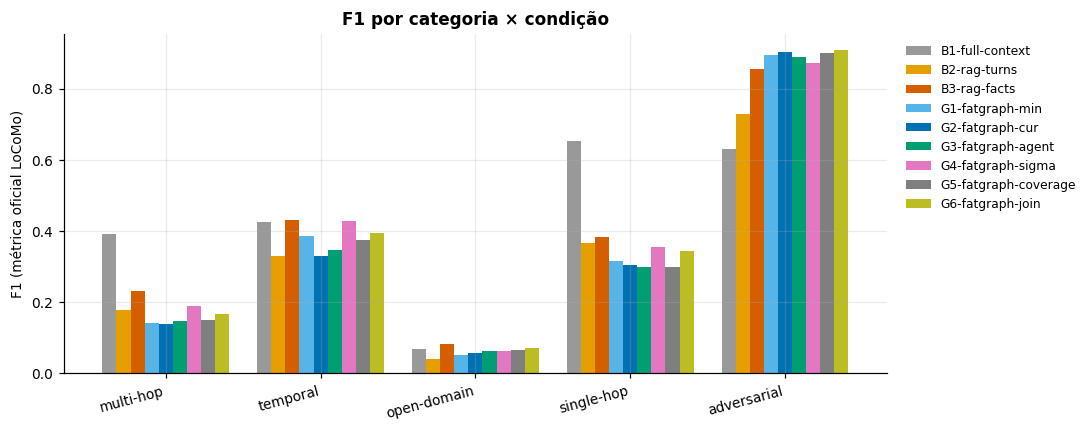

In [4]:
plot_f1_by_category(ctx); show()


## O que cada ingrediente adiciona

Barras acima de zero significam que o ingrediente ajudou naquela categoria.


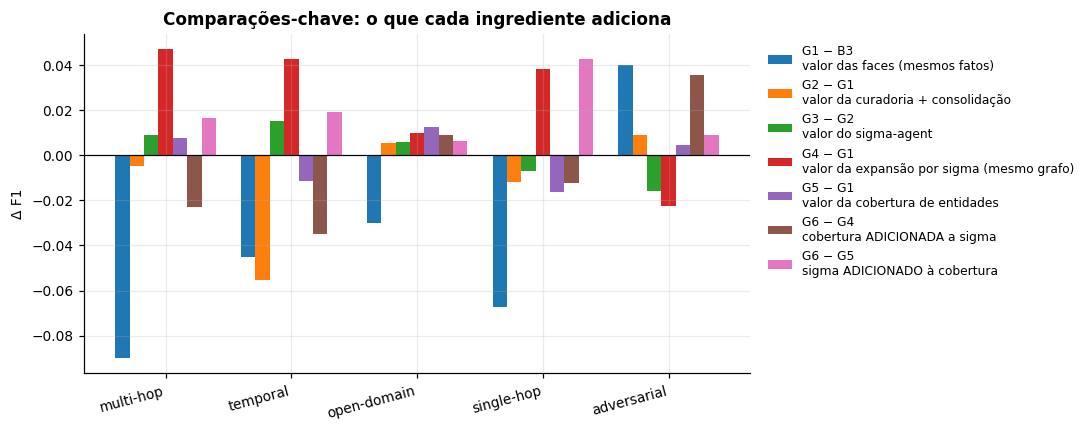

In [5]:
plot_deltas(ctx); show()


## Taxa de abstenção

Em `adversarial` abster-se **é** a resposta certa. Nas demais categorias,
abstenção alta indica que a recuperação não está encontrando a evidência.


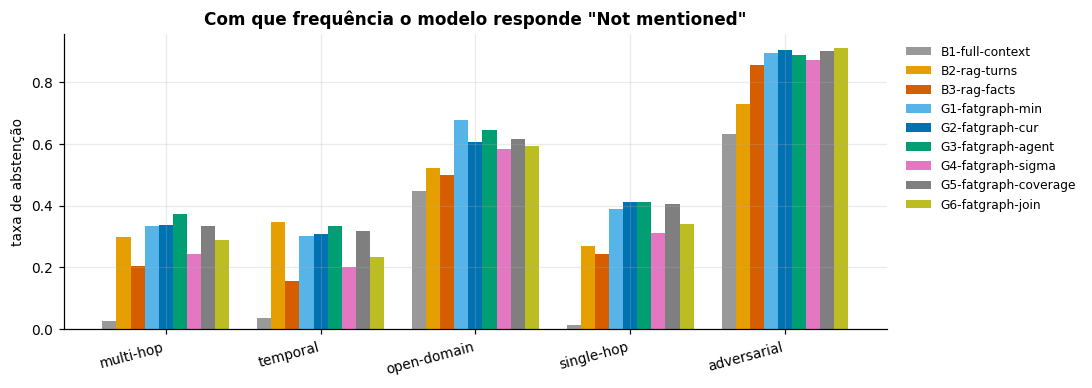

In [6]:
piv = ctx.f1.pivot_table(index='category', columns='condition',
                        values='abstention_rate', observed=True)
ax = piv.plot(kind='bar', figsize=(10, 3.6), color=colors(piv.columns), width=.82)
ax.set_ylabel('taxa de abstenção'); ax.set_xlabel('')
ax.set_title('Com que frequência o modelo responde "Not mentioned"')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right'); show()


## Onde as condições discordam

As perguntas em que uma condição acerta e a outra erra — é aqui que se lê
*qualitativamente* o que a topologia está fazendo.


In [7]:
preds = ctx.all_predictions()
if preds.empty:
    print('sem predictions.jsonl')
else:
    a, b = 'B3-rag-facts', 'G1-fatgraph-min'
    have = set(preds.condition.unique())
    if {a, b} <= have:
        key = ['question', 'category_name', 'gold']
        A = preds[preds.condition == a].set_index(key)
        B = preds[preds.condition == b].set_index(key)
        join = A[['prediction', 'f1']].join(
            B[['prediction', 'f1']], lsuffix=f'_{a}', rsuffix=f'_{b}', how='inner')
        join['delta'] = join[f'f1_{b}'] - join[f'f1_{a}']
        display(join.sort_values('delta', ascending=False).head(10))
        display(join.sort_values('delta').head(10))
    else:
        print(f'preciso de {a} e {b}; tenho {sorted(have)}')


,,,prediction_B3-rag-facts,f1_B3-rag-facts,prediction_G1-fatgraph-min,f1_G1-fatgraph-min,delta
question,category_name,gold,,,,,
Did Caroline make the black and white bowl in the photo?,adversarial,Not mentioned in the conversation,made by a friend,0.0,Not mentioned in the conversation,1.0,1.0
Where does John get his ideas from?,adversarial,Not mentioned in the conversation,a book,0.0,Not mentioned in the conversation,1.0,1.0
What game was the second tournament that Nate won based on?,single-hop,Street Fighter,Not mentioned in the conversation,0.0,Street Fighter,1.0,1.0
What are Jolene's favorite books?,single-hop,"Sapiens, Avalanche by Neal Stephenson",Not mentioned in the conversation,0.0,Sapiens; Avalanche by Neal Stephenson,1.0,1.0
Which game tournaments does John plan to organize besides CS:GO?,single-hop,Fortnite competitions,tournaments for computer games in his state,0.0,Fortnite competitions,1.0,1.0
What are Jolene's favorite books?,single-hop,"Sapiens, Avalanche by Neal Stephenson",Not mentioned in the conversation,0.0,Sapiens; Avalanche by Neal Stephenson,1.0,1.0
What does Joanna rely on for cheer and joy?,adversarial,Not mentioned in the conversation,creating stories and watching them come alive,0.0,Not mentioned in the conversation,1.0,1.0
What did Audrey organize with the neighbors' dogs?,single-hop,a doggy playdate,Not mentioned in the conversation,0.0,a doggy playdate,1.0,1.0
What is Joanna's favorite book series about?,adversarial,Not mentioned in the conversation,memory and relationships,0.0,Not mentioned in the conversation,1.0,1.0


,,,prediction_B3-rag-facts,f1_B3-rag-facts,prediction_G1-fatgraph-min,f1_G1-fatgraph-min,delta
question,category_name,gold,,,,,
What type of content does Dave post on his blog that inspired others to start their own cooking projects?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,making a car look like a beast,0.0,-1.0
What event did Maria participate in to show support for veterans' rights?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,agreed to help John's project to support milit...,0.0,-1.0
"What was the name of the pet that John had to say goodbye to on 3 June, 2023?",single-hop,Max,Max,1.0,Not mentioned in the conversation,0.0,-1.0
When is Melanie planning on going camping?,temporal,June 2023,June 2023,1.0,Not mentioned in the conversation,0.0,-1.0
"Which city was Calvin at on October 3, 2023?",temporal,Boston,Boston,1.0,Not mentioned in the conversation,0.0,-1.0
Where was Dave in the last two weeks of August 2023?,temporal,San Francisco,San Francisco,1.0,Not mentioned in the conversation,0.0,-1.0
What kind of food did Maria have on her dinner spread with her father?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,"salads, sandwiches, and homemade desserts",0.0,-1.0
What special items did Nate get for everyone at his gaming party?,single-hop,Custom controller decorations,custom controller decorations,1.0,Not mentioned in the conversation,0.0,-1.0
What does Calvin find energizing during the tour?,single-hop,Performing and connecting with the crowd,Performing and connecting with the crowd,1.0,Not mentioned in the conversation,0.0,-1.0


## Relatório completo em Markdown

Idêntico ao que `fgl report` imprime — mesma função, mesmos números.


In [8]:
print(ctx.report())


# Resultados — memória fatgraph no LoCoMo

F1 é a métrica oficial do LoCoMo (token-level, `task_eval/evaluation.py`), reportada para **todas** as categorias, inclusive adversarial. Nada foi filtrado nem subamostrado.


> ## ⚠️ Corrida suspeita — não interprete estes números
>
> **G4-fatgraph-sigma**
>   - o grafo é quase uma ESTRELA (81% dos vértices têm grau 1, 45% das meias-arestas estão nos dois maiores vértices, 21.3 faces não triviais em média) — sigma é redundante com phi e a cobertura por face não discrimina: esta condição vai reproduzir a G1 e o delta que ela deveria medir não existe neste grafo. A causa está no INGEST, não na recuperação: os fatos estão sendo ancorados em quem falou, não no que foi dito. Confira a extração e a resolução de entidades antes de interpretar qualquer número.
> **G5-fatgraph-coverage**
>   - o grafo é quase uma ESTRELA (81% dos vértices têm grau 1, 45% das meias-arestas estão nos dois maiores vértices, 21.3 faces não triviais em média) — sigma é red